In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


In [3]:
class State(TypedDict):
    message: Annotated[list[AnyMessage],add_messages]

In [4]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY", "")

In [7]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://aicredits.in/v1",
)

In [8]:
llm.invoke("hi man")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 9, 'total_tokens': 18, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}, 'cost': 0.000766699845714, 'cost_details': {'completion_cost_inr': 0.0006133598765712001, 'prompt_cost_inr': 0.00015333996914280003}, 'latency_ms': 696}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0950b7f384', 'id': 'chatcmpl-EDlzzX73joTWV0Iv3bKckgylJo1MJ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a00e9b-a049-7392-9247-ec601323fb37-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 9, 'total_tokens': 18, 'input_token_details': {'audi

In [ ]:
# Example with Groq
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.3-70b-versatile")
# Alternatively with OpenAI:
# from langchain_openai import ChatOpenAI
# llm = ChatOpenAI(model="gpt-4o-mini")

response = llm.invoke("Hey I am shivansh and I like to play hockey")
print(response.content)


Nice to meet you, Krish. Cricket is a fantastic sport, and I'm sure you must be excited to play it. Are you a fan of any particular cricket team or player? Do you have a favorite batting or bowling style? Let's chat about cricket!


In [17]:
response

AIMessage(content="Nice to meet you, Krish. Cricket is a fantastic sport, and I'm sure you must be excited to play it. Are you a fan of any particular cricket team or player? Do you have a favorite batting or bowling style? Let's chat about cricket!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 45, 'total_tokens': 99, 'completion_time': 0.148880323, 'completion_tokens_details': None, 'prompt_time': 0.004073302, 'prompt_tokens_details': None, 'queue_time': 0.050344098, 'total_time': 0.152953625}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a00e9c-9324-73f3-9b67-34841fc0d664-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 54, 'total_tokens': 99})

In [22]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_core.messages import AnyMessage, HumanMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [24]:
def Superbot(state:State)->dict:
    return {"messages":[llm.invoke(state["messages"])]}

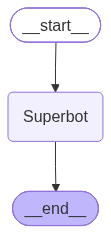

In [29]:
from IPython.display import Image, display

builder = StateGraph(State)
## Add node
builder.add_node("Superbot", Superbot)

builder.add_edge(START,"Superbot")

## Add Edges
builder.add_edge(START, "Superbot")
builder.add_edge("Superbot", END)

## Compile
graph = builder.compile()

## Display graph structure
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

In [30]:
input_message = HumanMessage(content="Hi, My name is shiva and I like cricket")
output = graph.invoke({"messages": [input_message]})
for msg in output["messages"]:
    msg.pretty_print()


================================ Human Message =================================

Hi, My name is shiva and I like cricket
================================== Ai Message ==================================

Nice to meet you, Shiva! Cricket is an amazing sport, isn't it? Which team or player is your favorite? Are you a fan of international cricket, IPL, or do you follow any other domestic leagues? Let's chat about cricket!


In [31]:
print("--- Streaming Updates ---")
for event in graph.stream(
    {"messages": [HumanMessage(content="Hello, can you give me 3 quick tips to improve batting in cricket?")]},
    stream_mode="updates"
):
    print(event)


--- Streaming Updates ---
{'Superbot': {'messages': [AIMessage(content="Here are three quick tips to improve your batting in cricket:\n\n1. **Watch the ball closely**: Focus on the ball from the moment it leaves the bowler's hand. This will help you pick up the length, speed, and movement of the ball, allowing you to make better decisions about which shots to play.\n\n2. **Play late and with a straight bat**: Try to play your shots as late as possible, which means waiting for the ball to come to you rather than reaching out for it. Also, use a straight bat whenever possible, especially when playing defensive shots, to reduce the risk of getting caught or bowled.\n\n3. **Use your feet to get into position**: Move your feet quickly to get into position to play your shots. This will help you to get into a balanced stance and generate power for your shots. For example, if you're playing a cover drive, take a step forward with your front foot to get into position to play the shot.\n\nRememb

In [32]:
print("--- Streaming Values ---")
for state_snapshot in graph.stream(
    {"messages": [HumanMessage(content="Tell me one quick fact about cricket history.")]},
    stream_mode="values"
):
    print(f"Total messages in state: {len(state_snapshot['messages'])}")


--- Streaming Values ---
Total messages in state: 1
Total messages in state: 2
